In [ ]:
from google.colab import files
uploaded = files.upload()


Saving archive (1).zip to archive (1) (1).zip


In [ ]:
import zipfile
import os

zip_path = "archive (1).zip"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall("dataset")

print("Files extracted successfully!")


Files extracted successfully!


In [ ]:
os.listdir("dataset")


['Default.xlsx']

In [ ]:
import pandas as pd

file_path = "dataset/Default.xlsx"
df = pd.read_excel(file_path)

df.head()


/usr/local/lib/python3.12/dist-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


,Unnamed: 0,default,student,balance,income
0,1,No,No,729.526495,44361.625074
1,2,No,Yes,817.180407,12106.134700
2,3,No,No,1073.549164,31767.138947
3,4,No,No,529.250605,35704.493935
4,5,No,No,785.655883,38463.495879


In [ ]:
df.info()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  10000 non-null  int64  
 1   default     10000 non-null  object 
 2   student     10000 non-null  object 
 3   balance     10000 non-null  float64
 4   income      10000 non-null  float64
dtypes: float64(2), int64(1), object(2)
memory usage: 390.8+ KB


,Unnamed: 0,balance,income
count,10000.00000,10000.000000,10000.000000
mean,5000.50000,835.374886,33516.981876
std,2886.89568,483.714985,13336.639563
min,1.00000,0.000000,771.967729
25%,2500.75000,481.731105,21340.462903
50%,5000.50000,823.636973,34552.644802
75%,7500.25000,1166.308386,43807.729272
max,10000.00000,2654.322576,73554.233495


In [ ]:
df.columns


Index(['Unnamed: 0', 'default', 'student', 'balance', 'income'], dtype='object')

In [ ]:
df['default'].value_counts()


,count
default,
No,9667
Yes,333


In [ ]:
df['debt_to_income_ratio'] = df['balance'] / df['income']

df[['income', 'balance', 'debt_to_income_ratio']].head()

,income,balance,debt_to_income_ratio
0,44361.625074,729.526495,0.016445
1,12106.134700,817.180407,0.067501
2,31767.138947,1073.549164,0.033794
3,35704.493935,529.250605,0.014823
4,38463.495879,785.655883,0.020426


In [ ]:
def classify_risk(row):
    if row['debt_to_income_ratio'] > 0.5:
        return "High Risk"
    elif row['debt_to_income_ratio'] > 0.3:
        return "Medium Risk"
    else:
        return "Low Risk"

df['Risk_Level'] = df.apply(classify_risk, axis=1)

df[['debt_to_income_ratio', 'Risk_Level']].head()


,debt_to_income_ratio,Risk_Level
0,0.016445,Low Risk
1,0.067501,Low Risk
2,0.033794,Low Risk
3,0.014823,Low Risk
4,0.020426,Low Risk


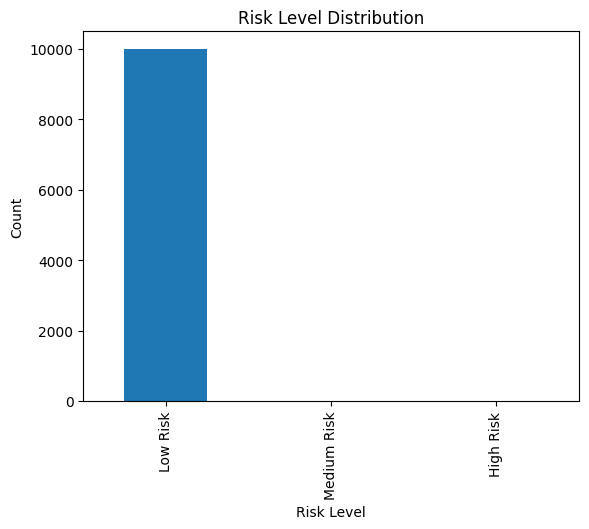

In [ ]:
import matplotlib.pyplot as plt

df['Risk_Level'].value_counts().plot(kind='bar')
plt.title("Risk Level Distribution")
plt.xlabel("Risk Level")
plt.ylabel("Count")
plt.show()
